
▶ Showing LLC_dataset01: LLC_dataset01_1_200_AA.nk


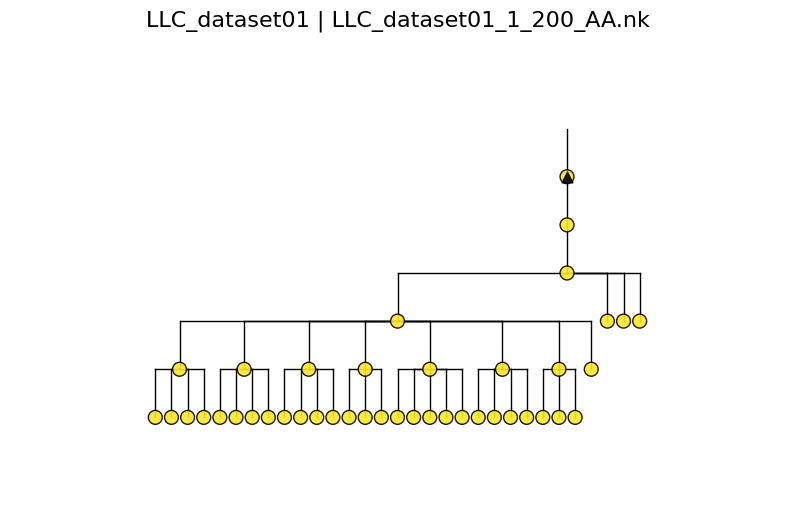


▶ Showing LLC_dataset02: LLC_dataset02_1_200_AA.nk


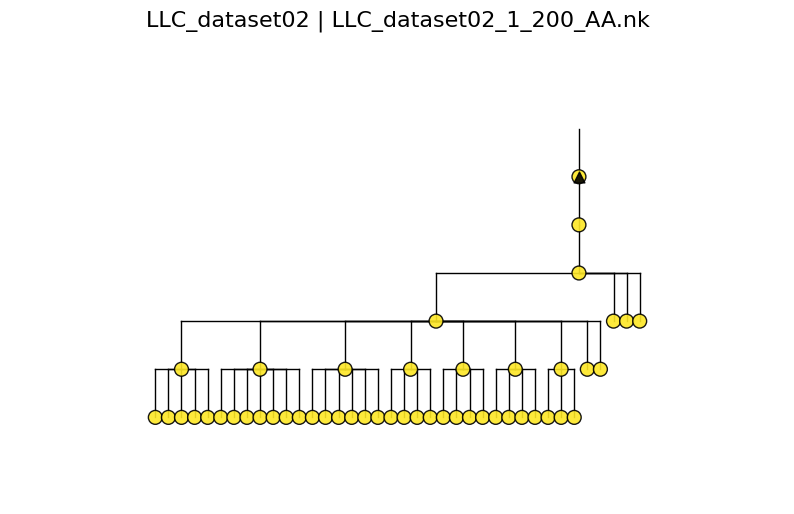


▶ Showing LLC_dataset03: LLC_dataset03_1_200_AA.nk


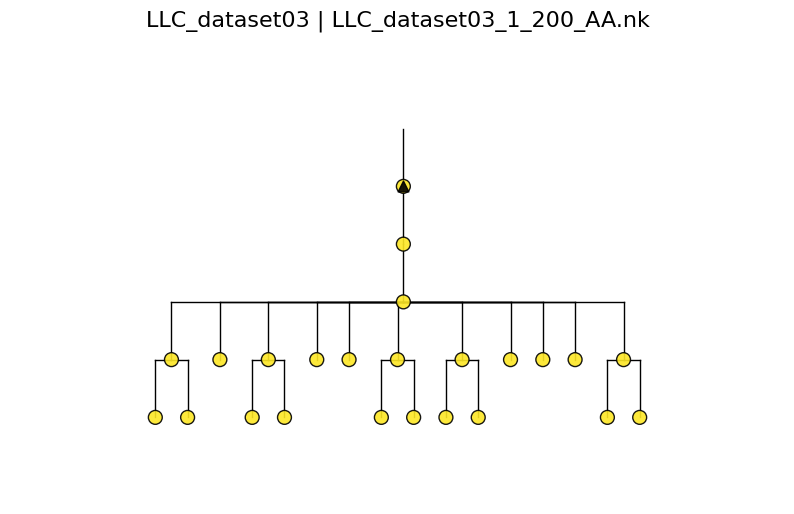


▶ Showing LLC_dataset04: LLC_dataset04_1_200_AA.nk


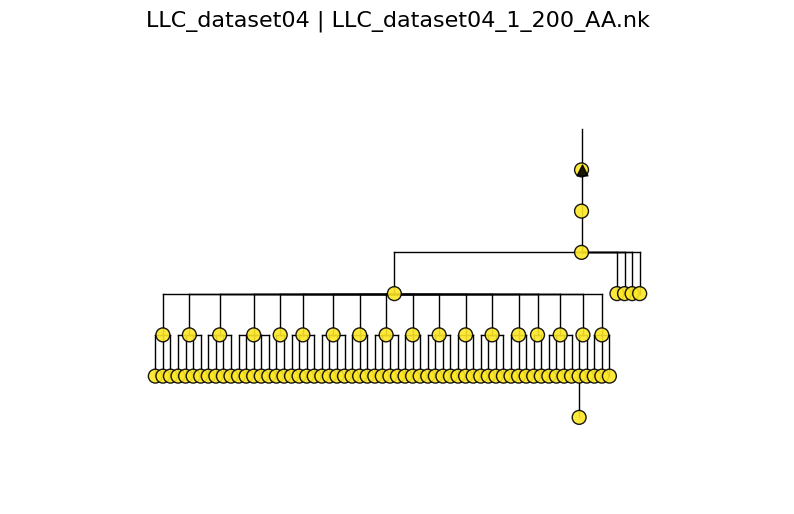


▶ Showing LLC_dataset05: LLC_dataset05_1_200_AA.nk


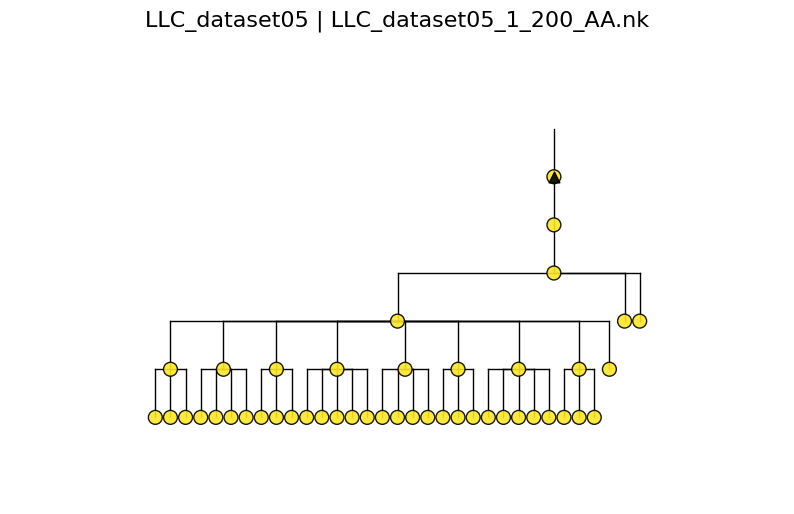


▶ Showing LLC_dataset06: LLC_dataset06_1_200_AA.nk


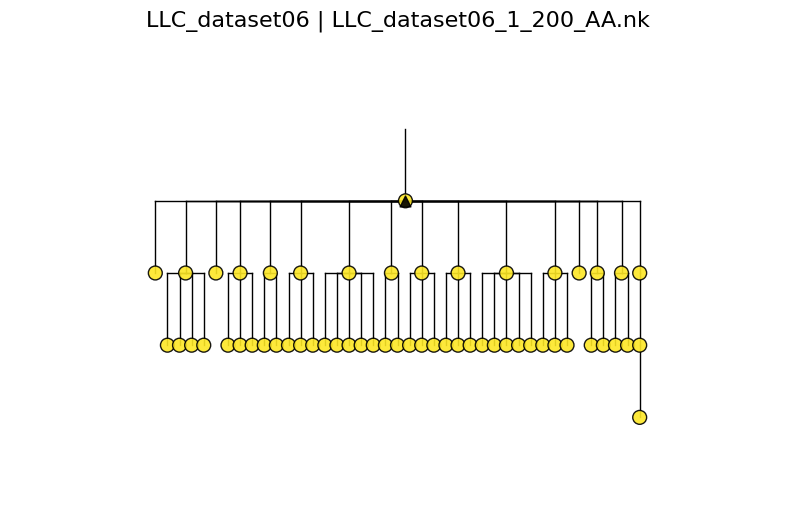


▶ Showing LLC_dataset07: LLC_dataset07_1_200_AA.nk


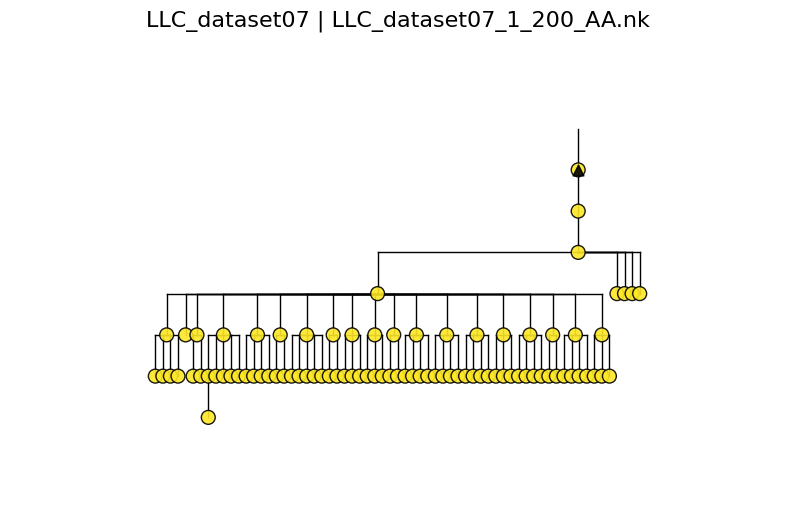


▶ Showing LLC_dataset08: LLC_dataset08_1_200_AA.nk


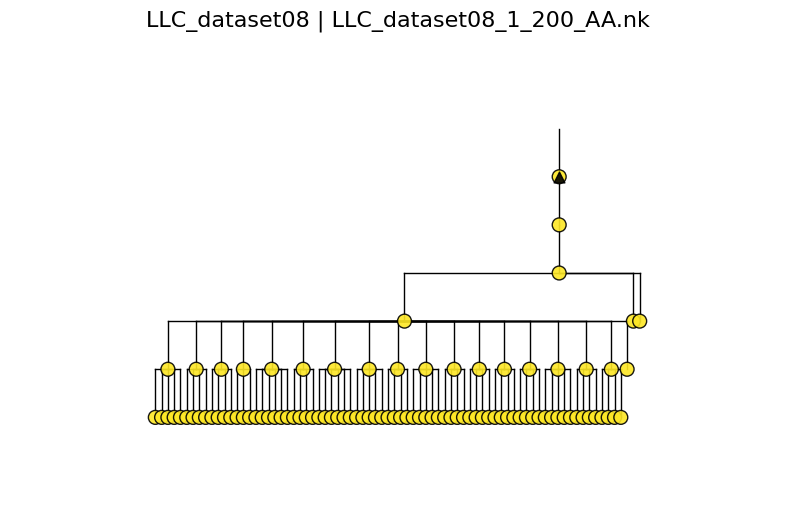


▶ Showing LLC_dataset09: LLC_dataset09_1_200_AA.nk


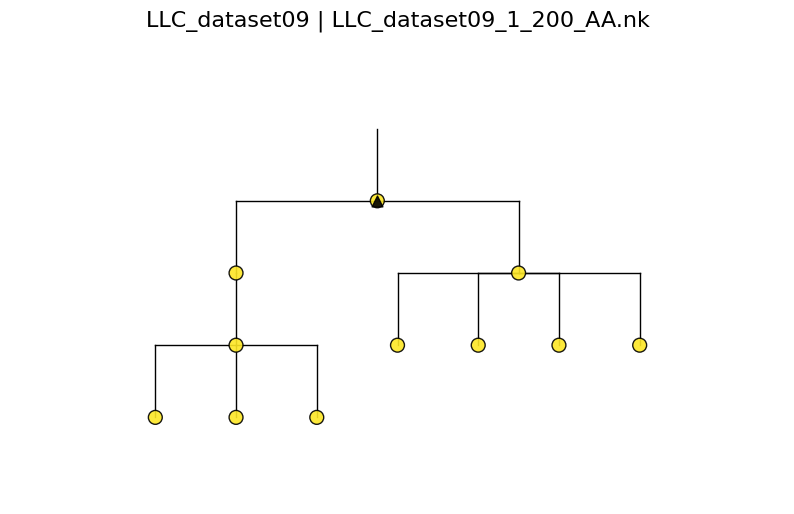


▶ Showing LLC_dataset10: LLC_dataset10_1_200_AA.nk


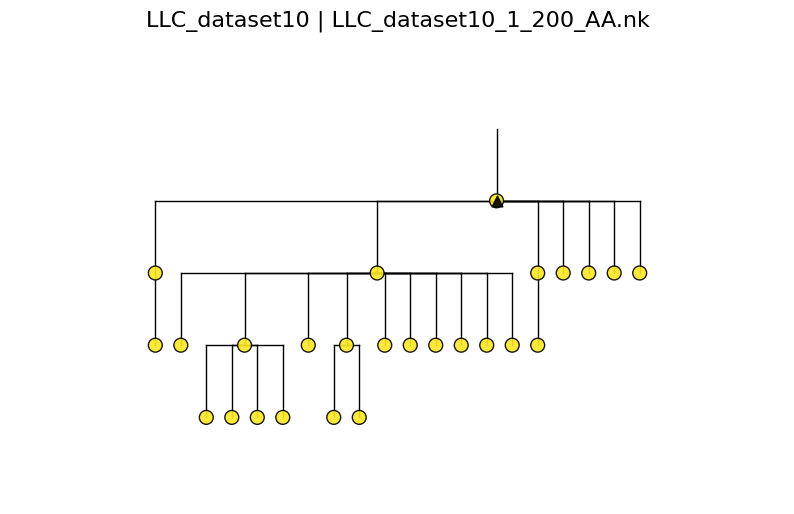


▶ Showing LLC_dataset11: LLC_dataset11_1_200_AA.nk


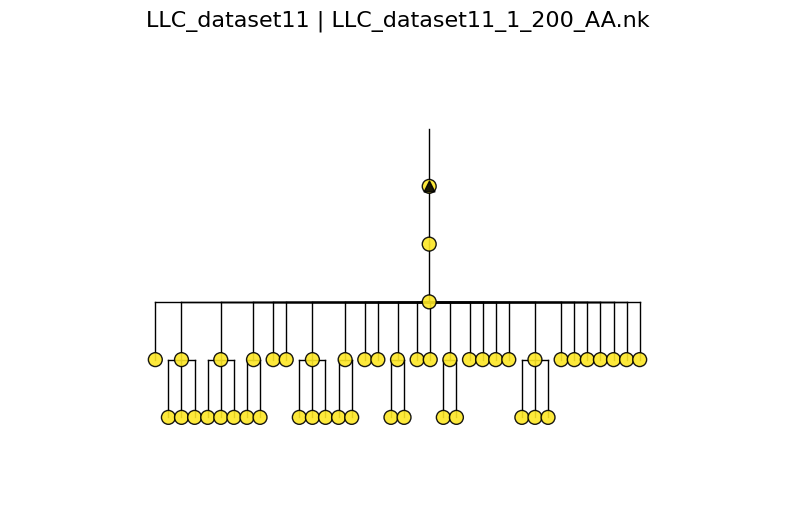


▶ Showing LLC_dataset12: LLC_dataset12_1_200_AA.nk


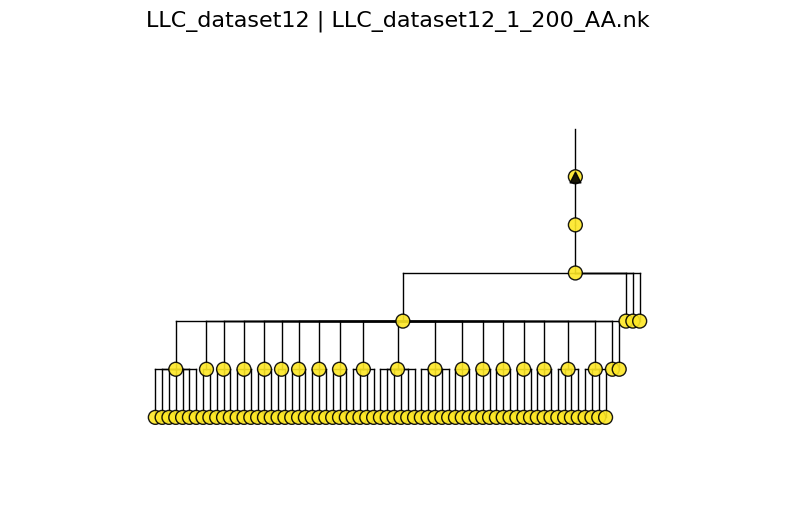


▶ Showing LLC_dataset13: LLC_dataset13_1_200_AA.nk


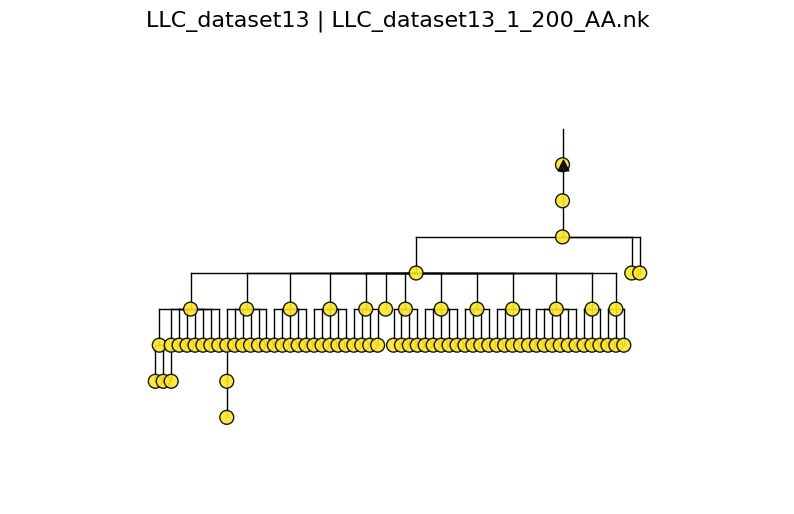


▶ Showing LLC_dataset14: LLC_dataset14_1_200_AA.nk


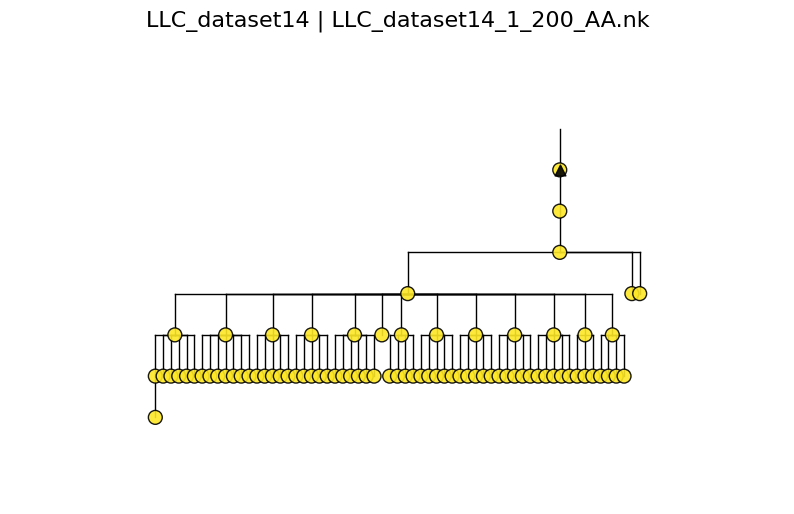


▶ Showing LLC_dataset15: LLC_dataset15_1_200_AA.nk


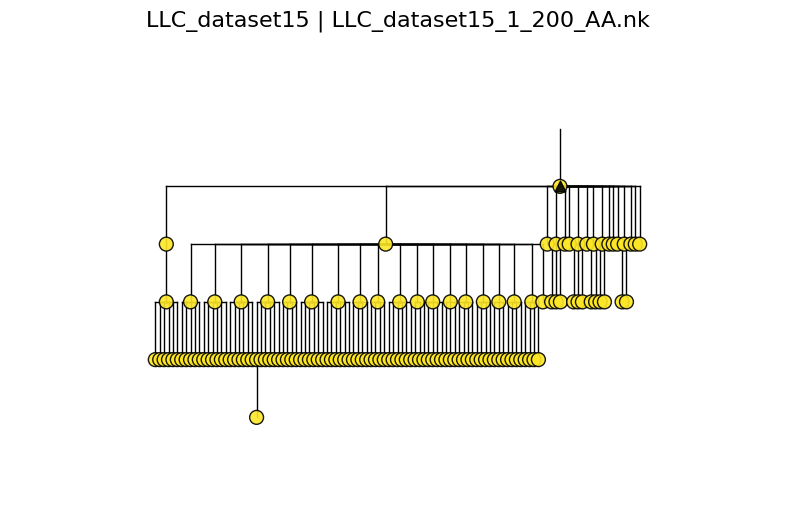


▶ Showing LLC_dataset16: LLC_dataset16_1_200_AA.nk


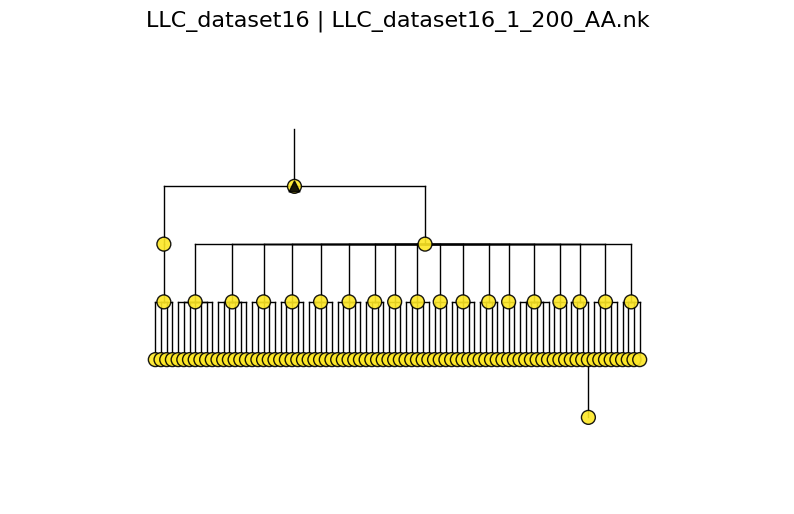


▶ Showing LLC_dataset17: LLC_dataset17_1_200_AA.nk


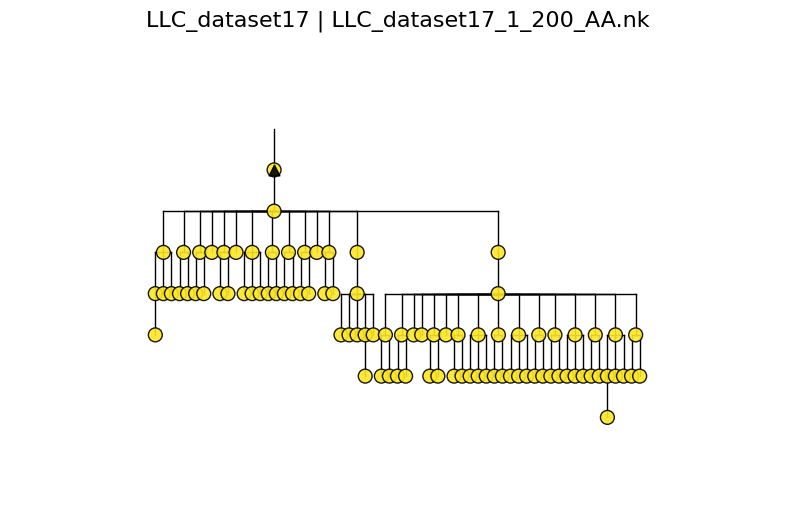


▶ Showing LLC_dataset18: LLC_dataset18_1_200_AA.nk


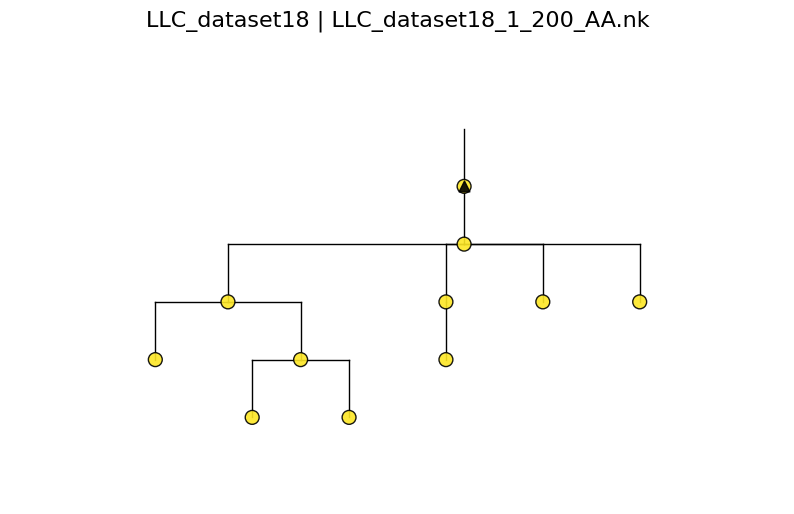


▶ Showing LLC_dataset19: LLC_dataset19_1_200_AA.nk


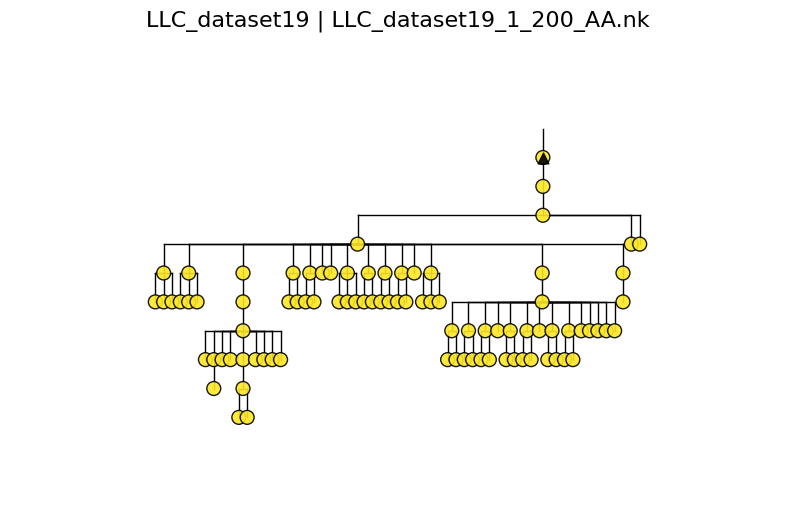


▶ Showing LLC_dataset20: LLC_dataset20_1_200_AA.nk


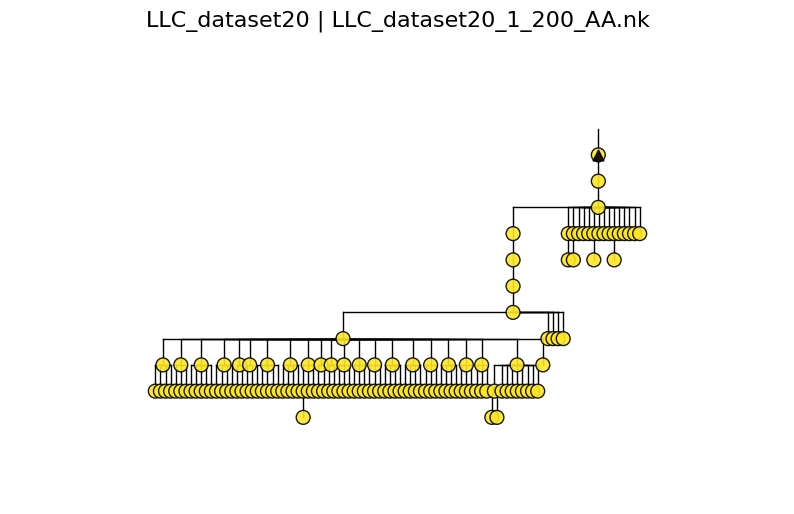


▶ Showing LLC_dataset21: LLC_dataset21_1_200_AA.nk


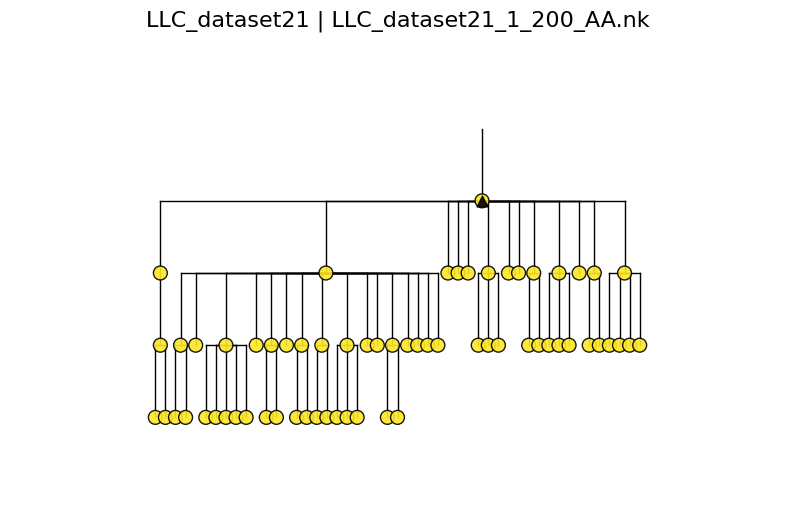


▶ Showing LLC_dataset22: LLC_dataset22_1_200_AA.nk


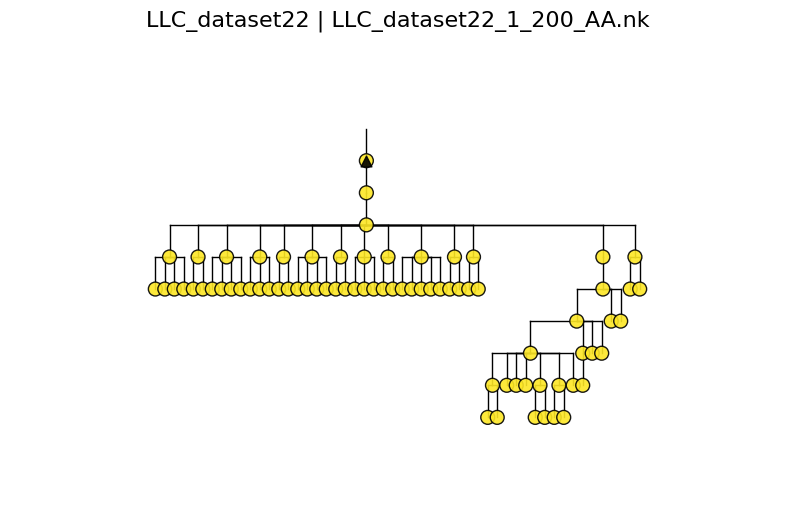


▶ Showing LLC_dataset23: LLC_dataset23_1_200_AA.nk


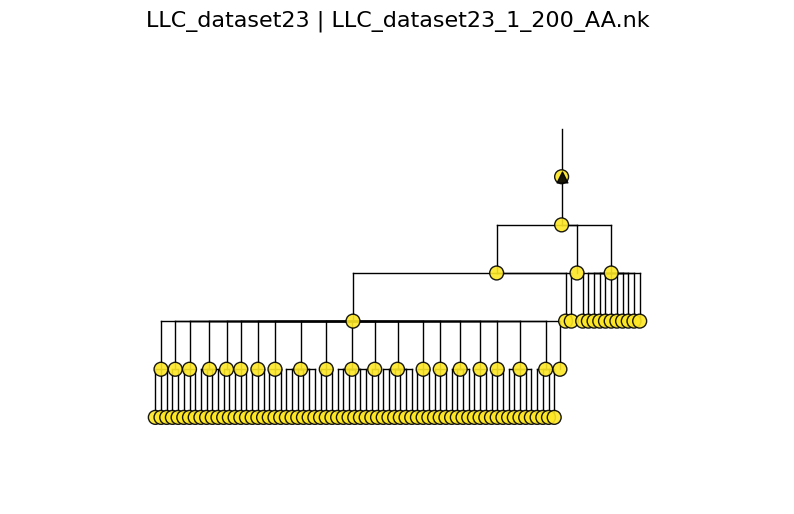


▶ Showing LLC_dataset24: LLC_dataset24_1_200_AA.nk


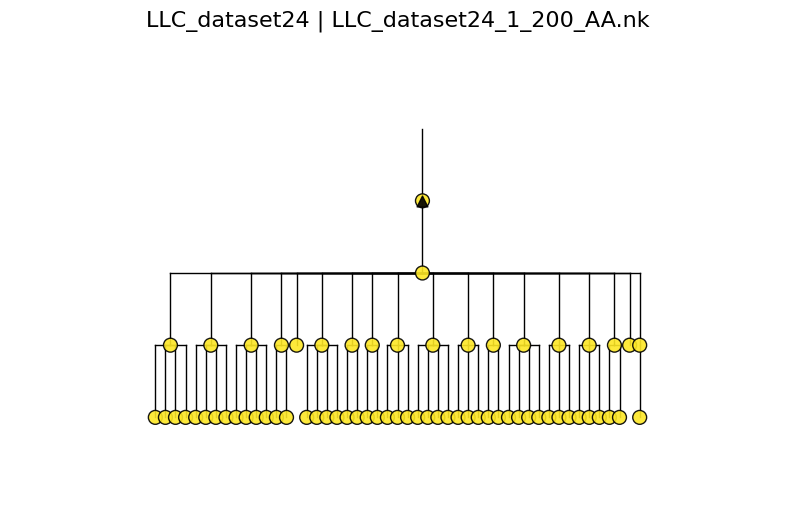


▶ Showing LLC_dataset25: LLC_dataset25_1_200_AA.nk


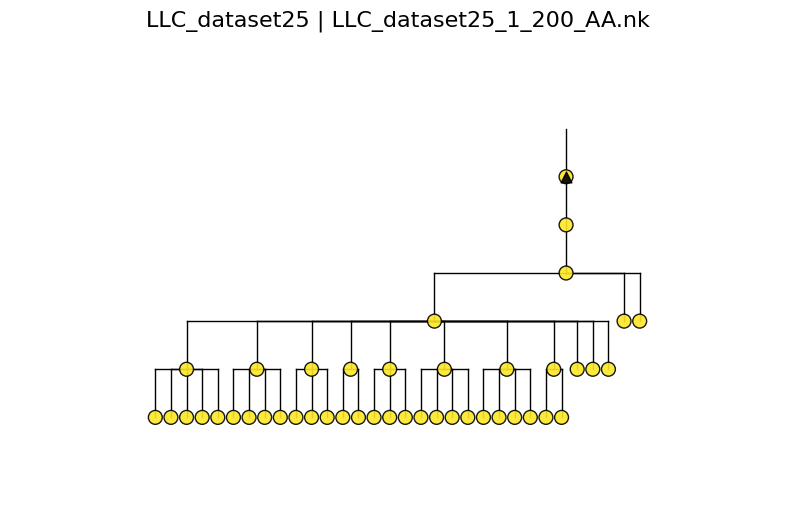


▶ Showing LLC_dataset26: LLC_dataset26_1_200_AA.nk


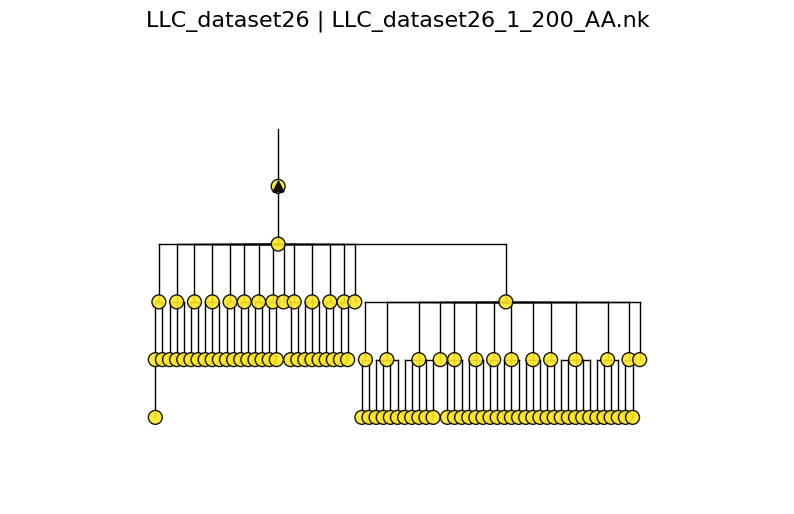


▶ Showing LLC_dataset27: LLC_dataset27_1_200_AA.nk


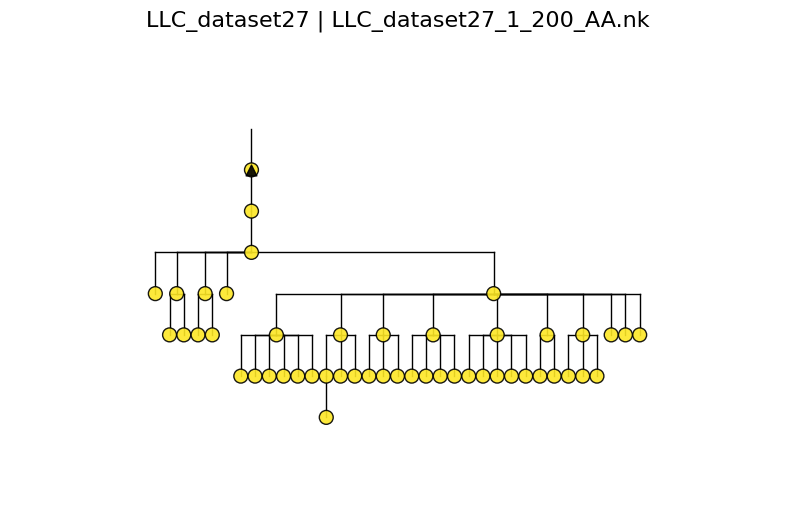


▶ Showing LLC_dataset28: LLC_dataset28_1_200_AA.nk


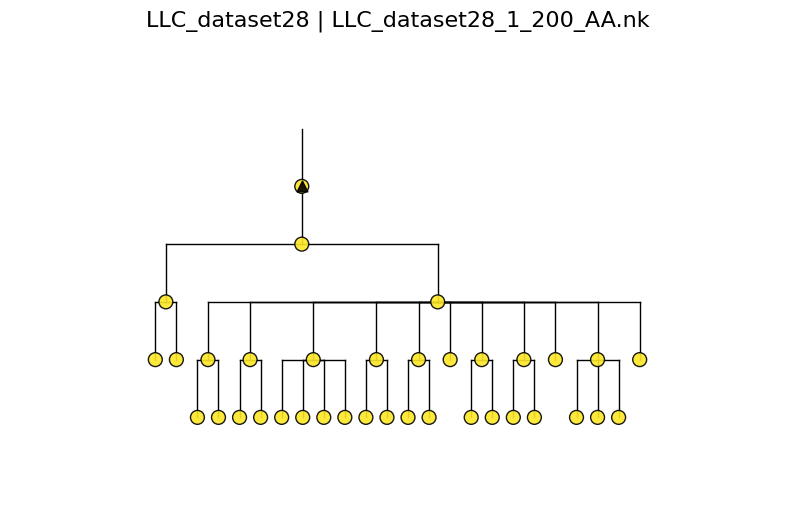


▶ Showing LLC_dataset29: LLC_dataset29_1_200_AA.nk


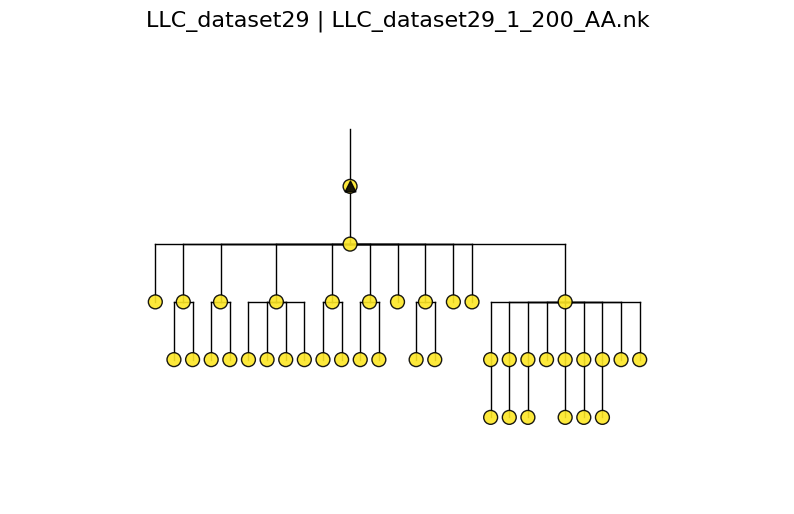


▶ Showing LLC_dataset30: LLC_dataset30_1_200_AA.nk


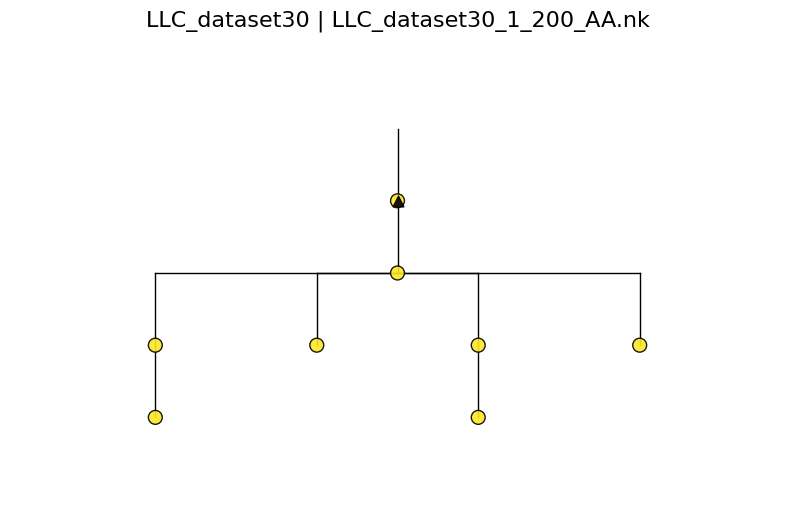


▶ Showing LLC_dataset31: LLC_dataset31_1_200_AA.nk


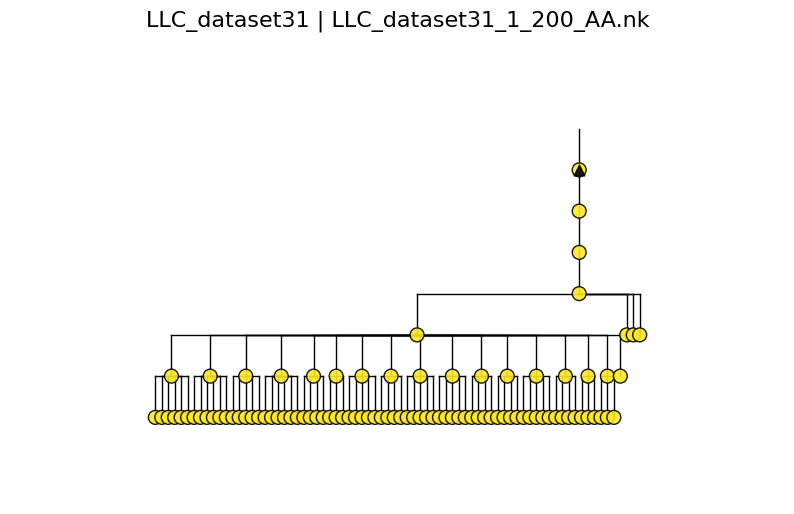


▶ Showing LLC_dataset32: LLC_dataset32_1_200_AA.nk


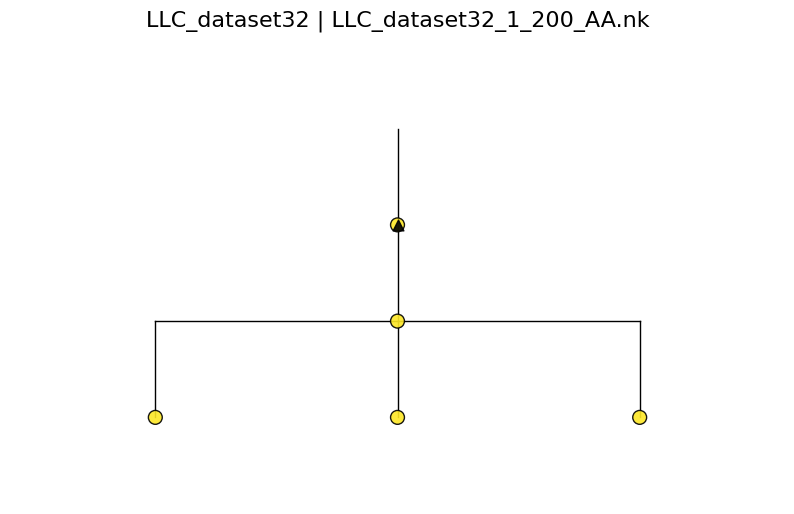


▶ Showing LLC_dataset33: LLC_dataset33_1_200_AA.nk


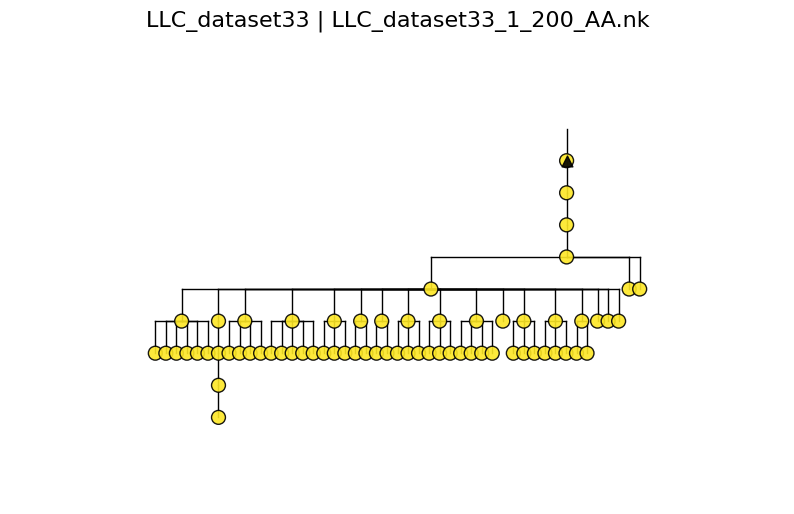


▶ Showing LLC_dataset34: LLC_dataset34_1_200_AA.nk


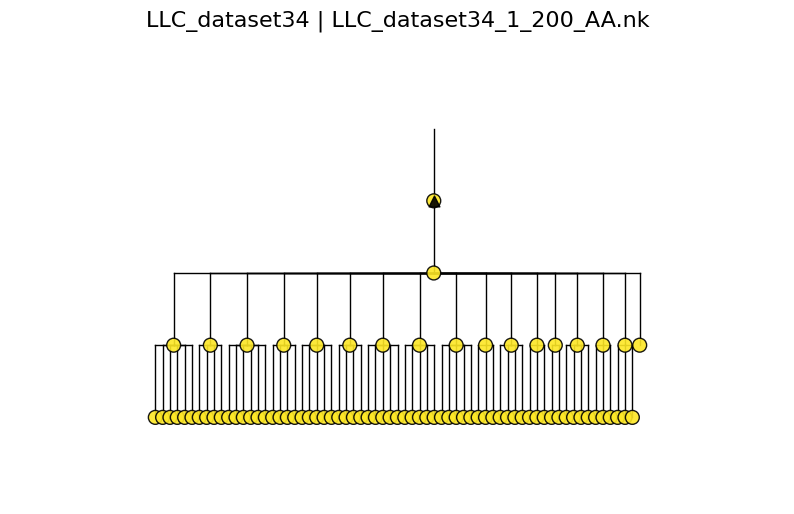


▶ Showing LLC_dataset35: LLC_dataset35_1_200_AA.nk


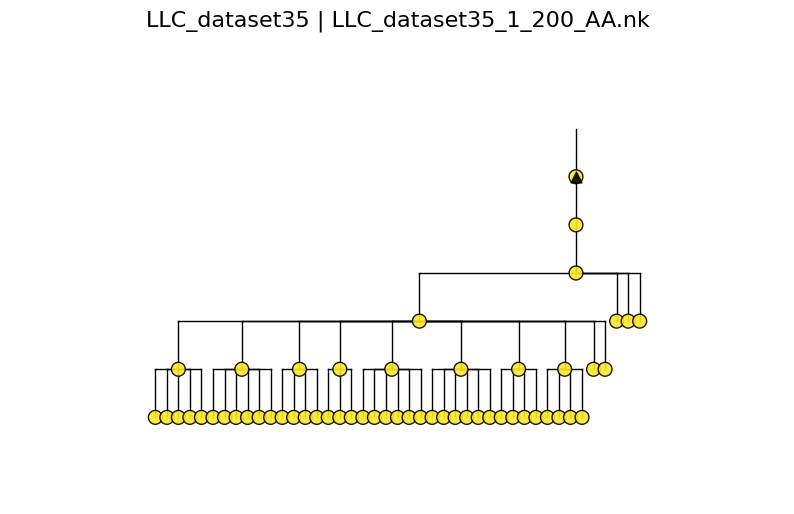


▶ Showing LLC_dataset36: LLC_dataset36_1_200_AA.nk


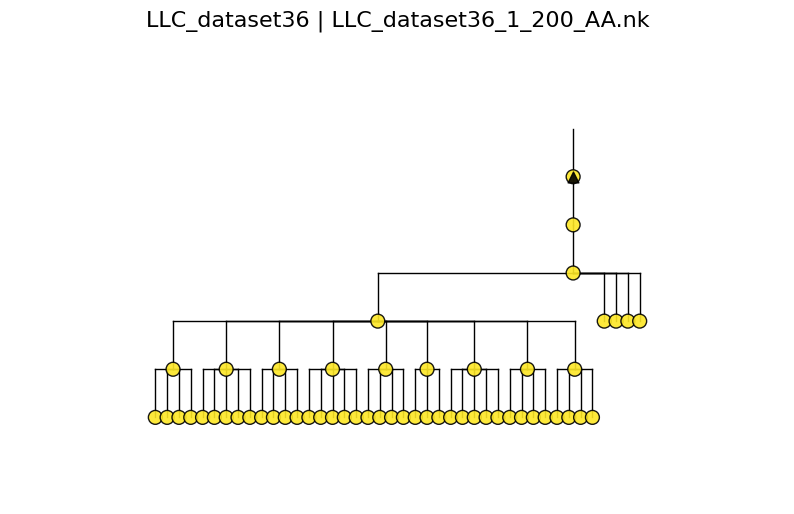


▶ Showing LLC_dataset37: LLC_dataset37_1_200_AA.nk


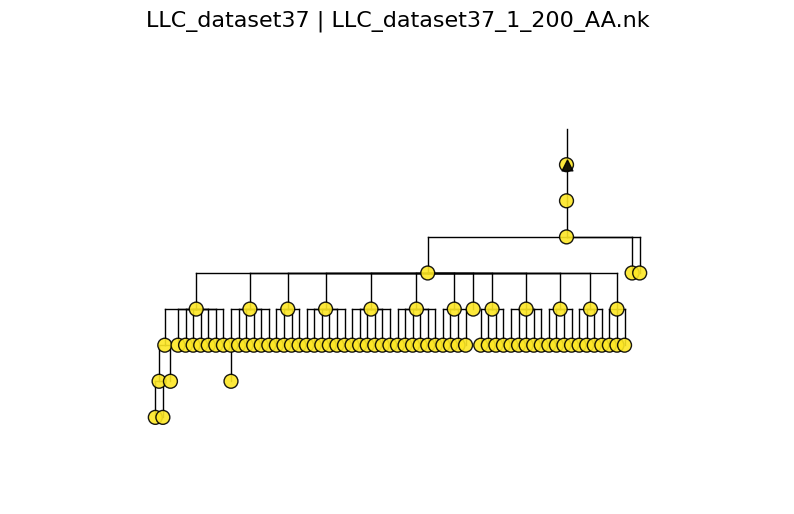


▶ Showing LLC_dataset38: LLC_dataset38_1_200_AA.nk


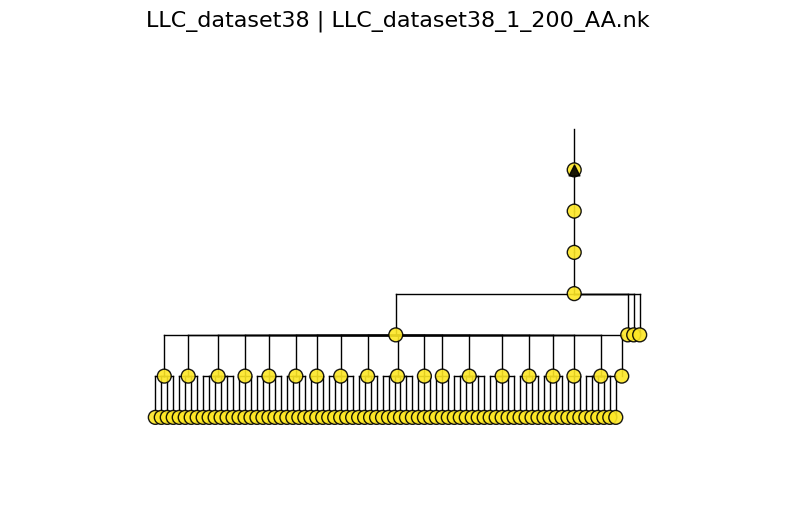


▶ Showing LLC_dataset39: LLC_dataset39_1_200_AA.nk


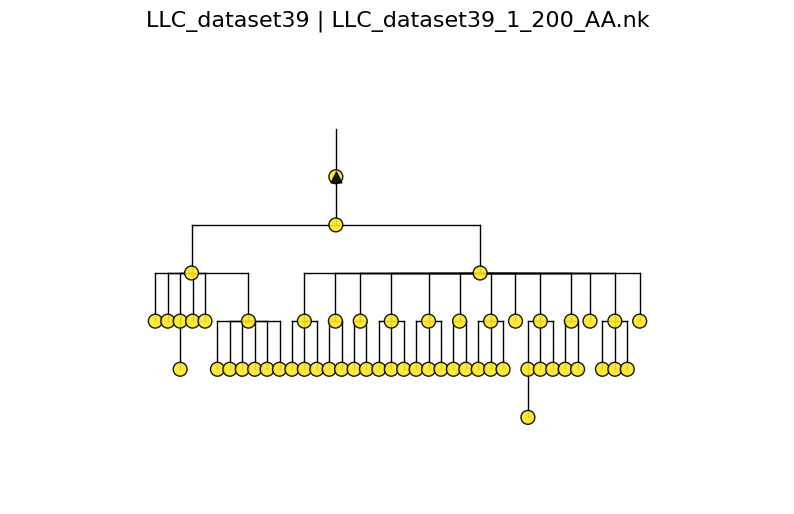


▶ Showing LLC_dataset40: LLC_dataset40_1_200_AA.nk


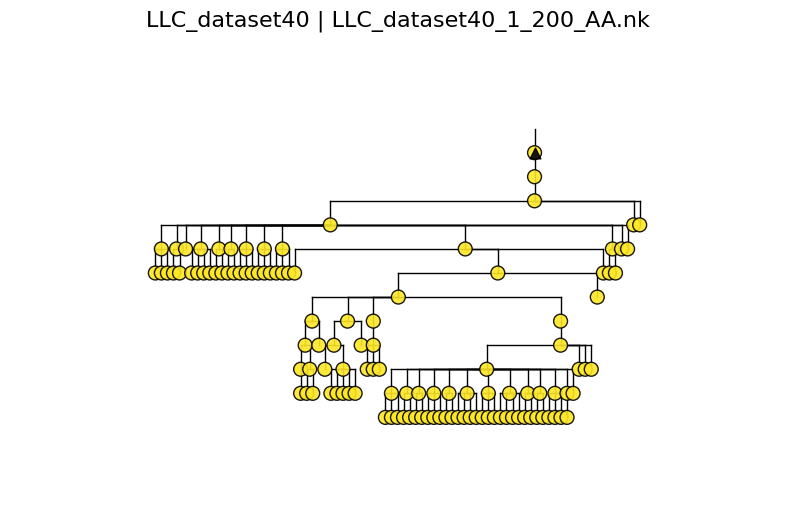


▶ Showing LLC_dataset41: LLC_dataset41_1_200_AA.nk


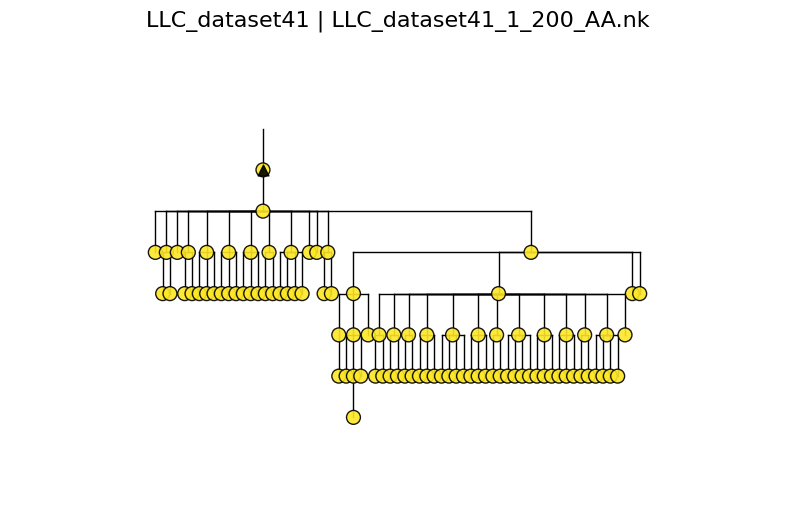


▶ Showing LLC_dataset42: LLC_dataset42_1_200_AA.nk


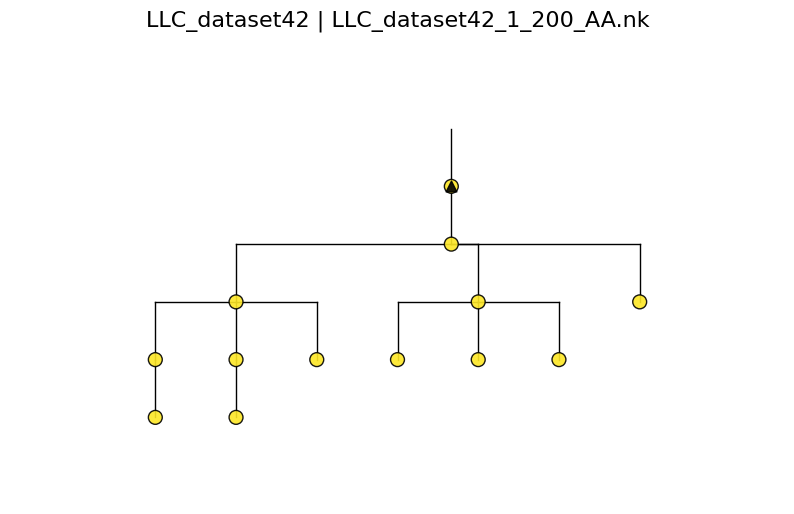


▶ Showing LLC_dataset43: LLC_dataset43_1_200_AA.nk


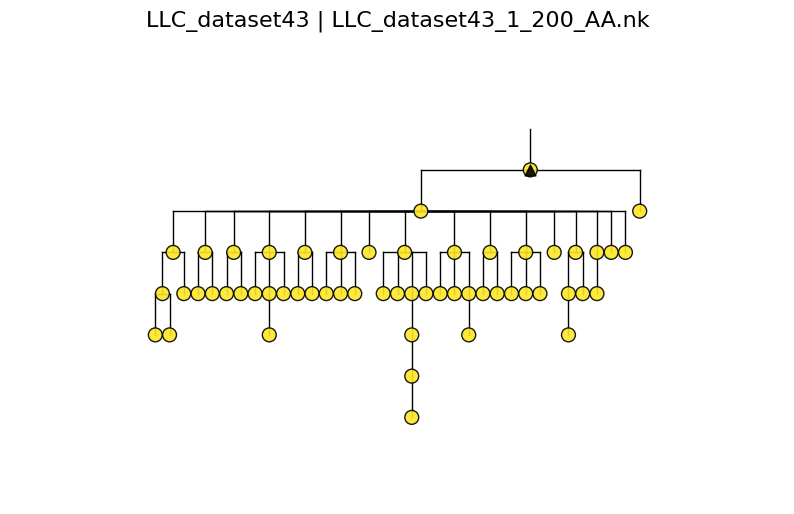


▶ Showing LLC_dataset44: LLC_dataset44_1_200_AA.nk


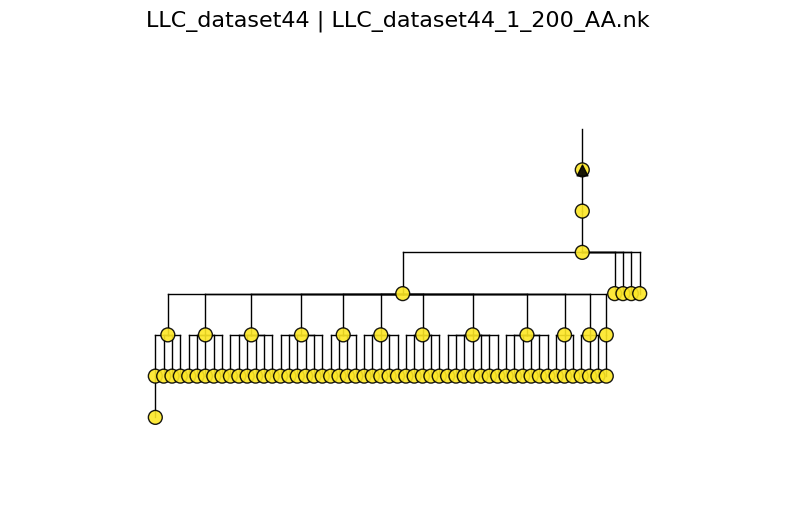


▶ Showing LLC_dataset45: LLC_dataset45_1_200_AA.nk


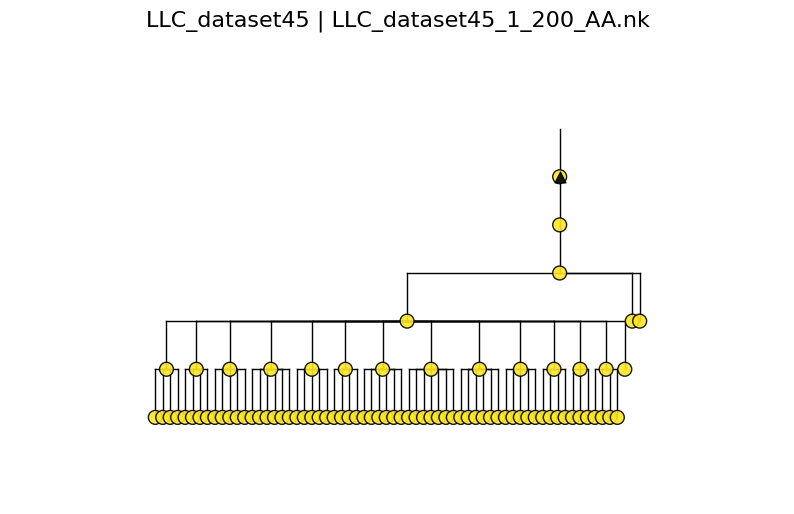


▶ Showing LLC_dataset46: LLC_dataset46_1_200_AA.nk


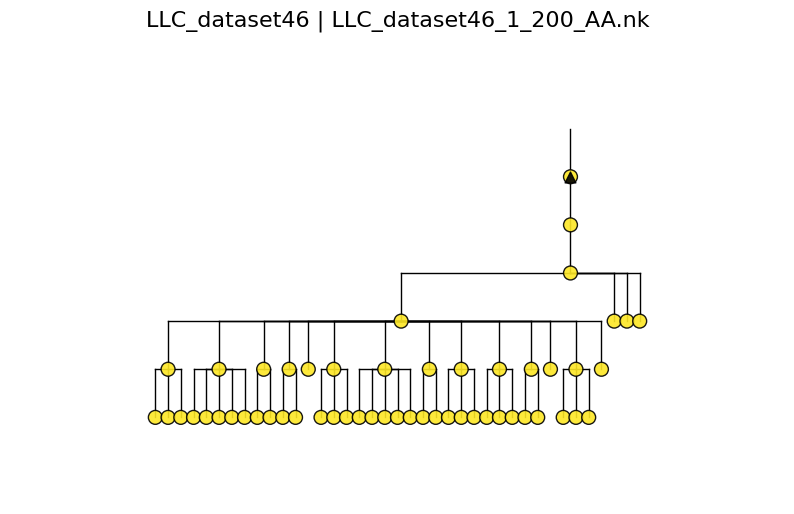


▶ Showing LLC_dataset47: LLC_dataset47_1_200_AA.nk


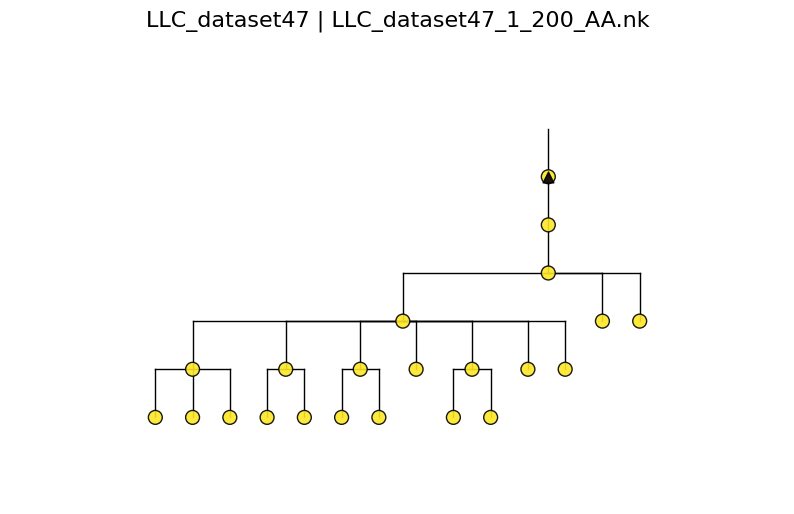


▶ Showing LLC_dataset48: LLC_dataset48_1_200_AA.nk


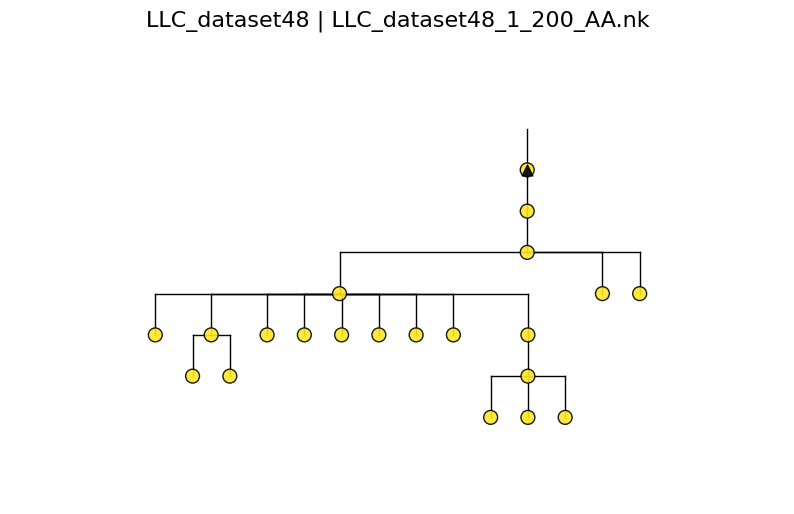


▶ Showing LLC_dataset49: LLC_dataset49_1_200_AA.nk


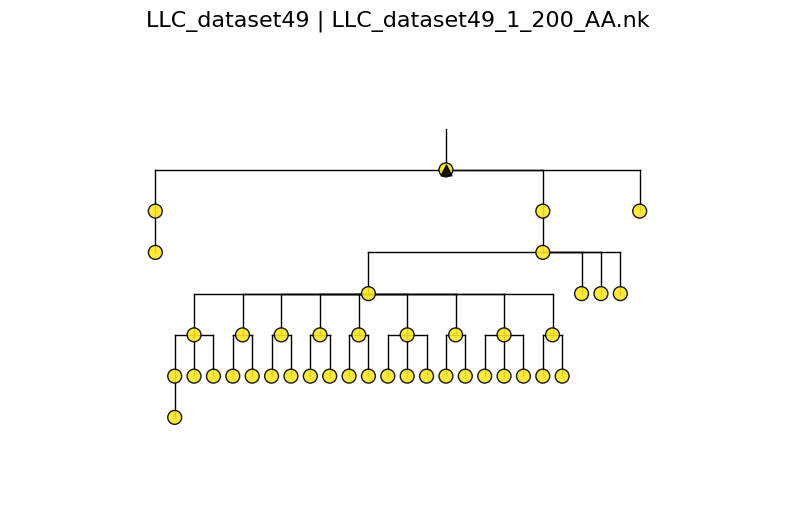


▶ Showing LLC_dataset50: LLC_dataset50_1_200_AA.nk


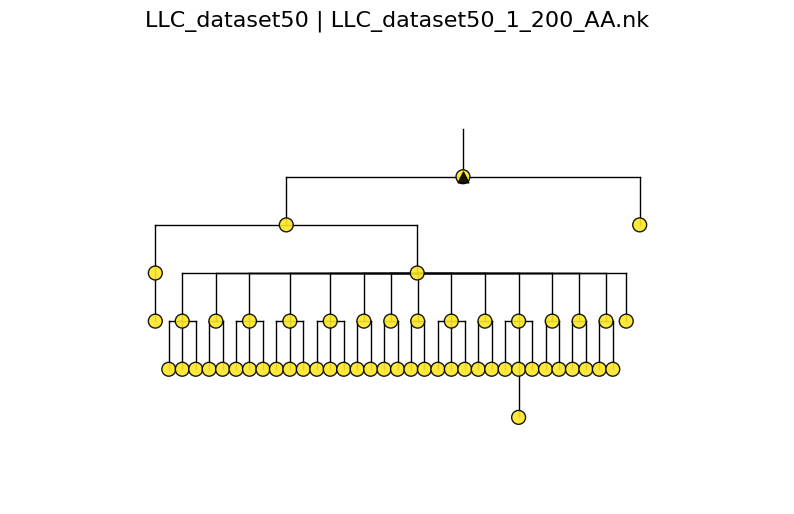


▶ Showing LLC_dataset51: LLC_dataset51_1_200_AA.nk


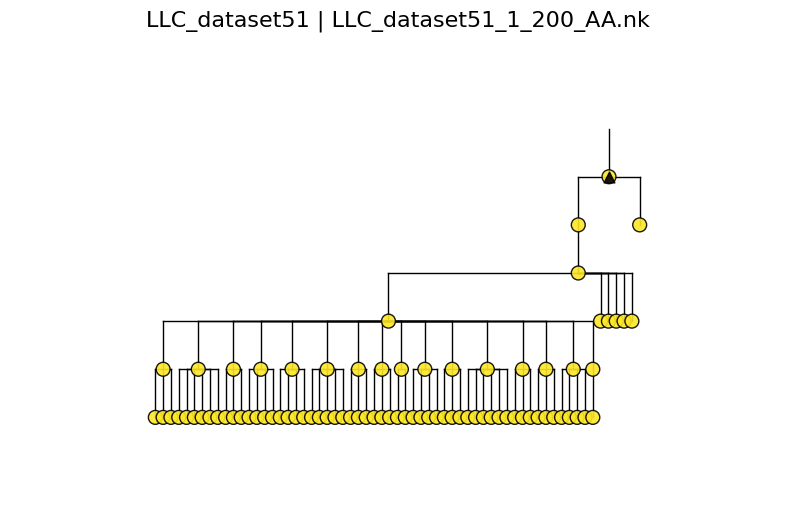


▶ Showing LLC_dataset52: LLC_dataset52_1_200_AA.nk


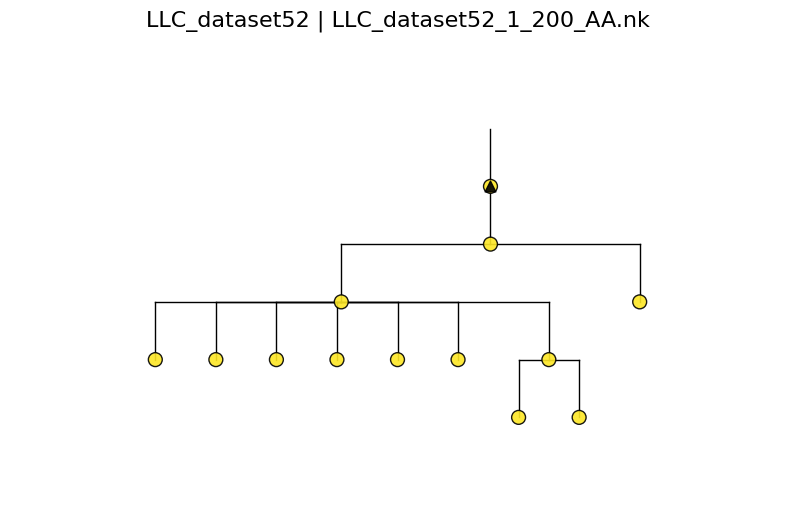


▶ Showing LLC_dataset53: LLC_dataset53_1_200_AA.nk


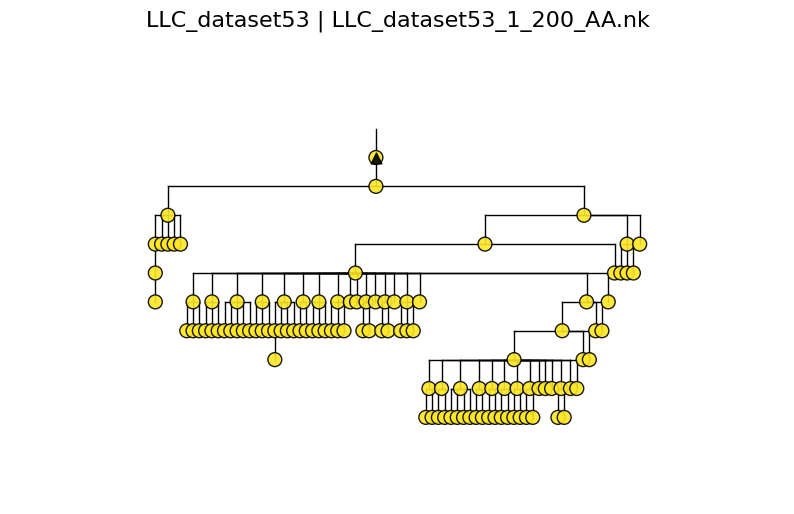


▶ Showing LLC_dataset54: LLC_dataset54_1_200_AA.nk


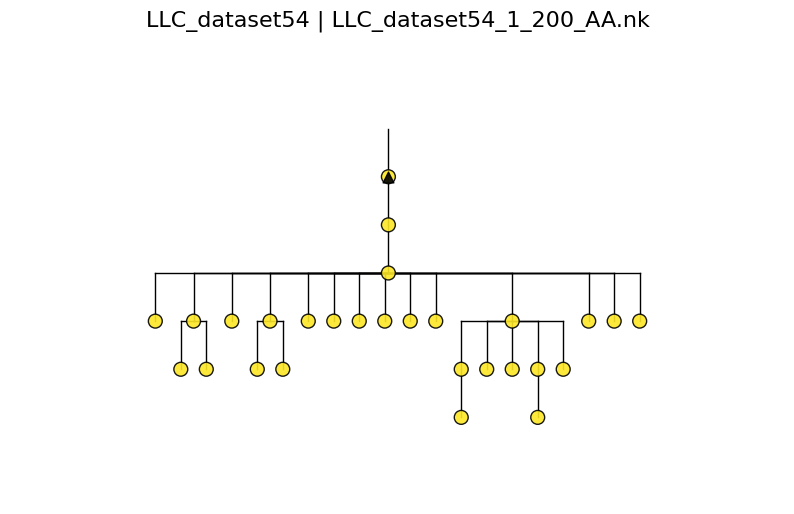


▶ Showing LLC_dataset55: LLC_dataset55_1_200_AA.nk


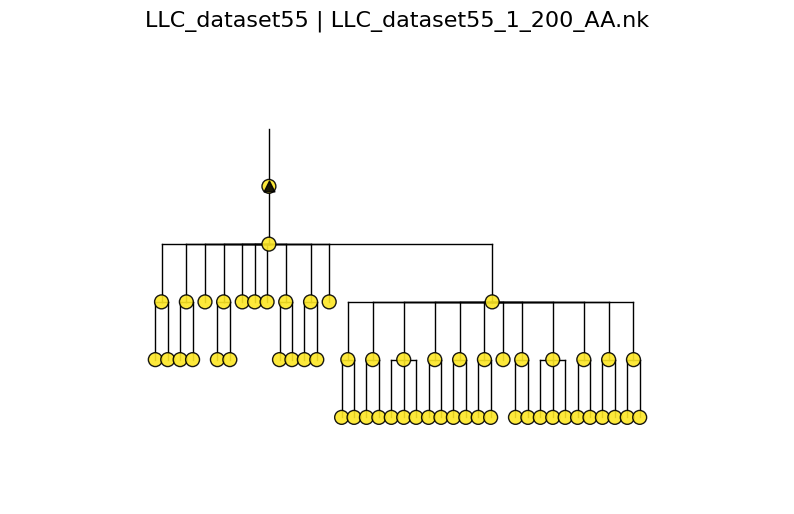


▶ Showing LLC_dataset56: LLC_dataset56_1_200_AA.nk


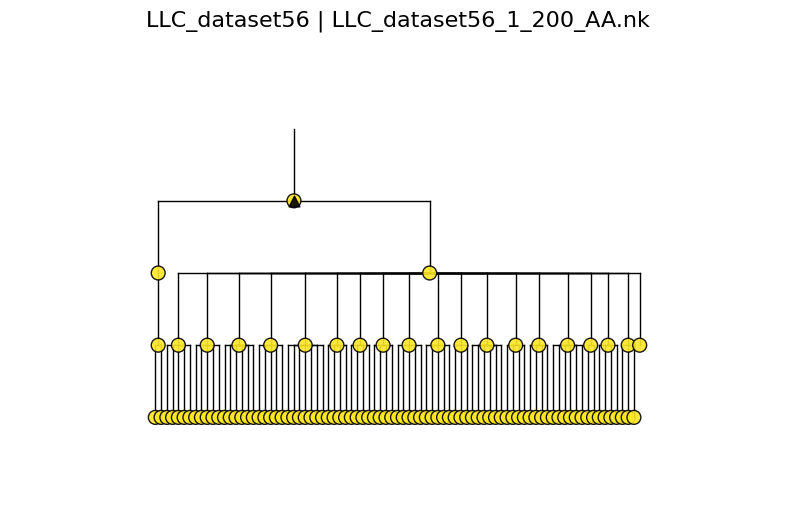


▶ Showing LLC_dataset57: LLC_dataset57_1_200_AA.nk


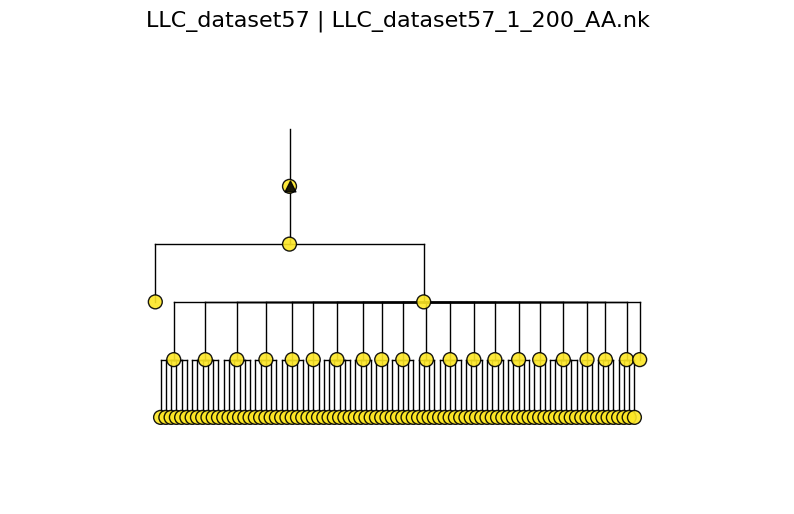


################################################################################
DONE VISUALIZING DATASETS
✅ shown: 57
⏭️ skipped (missing outputs): 0
################################################################################


In [2]:
import os
import re
import sys
from ete3 import Tree
from matplotlib import cm
import mplcursors
import numpy as np
import matplotlib.pyplot as plt


def plot_newick_bcellTree(newick, node_weights, title_name="Tree"):
    def rectangular_layout(tree):
        positions = {}
        x_offset = 0
        y_offset = 0
        level_spacing = 50
        sibling_spacing = 100

        def assign_positions(node, y):
            nonlocal x_offset
            if node.is_leaf():
                positions[node.name] = (x_offset, y)
                x_offset += sibling_spacing
            else:
                child_xs = []
                for child in node.children:
                    assign_positions(child, y - level_spacing)
                    child_xs.append(positions[child.name][0])
                positions[node.name] = (sum(child_xs) / len(child_xs), y)

        assign_positions(tree, y_offset)
        return positions

    node_info = {k: f"Node_name: {k}\n\nAbundancy: {int(v)}" for k, v in node_weights.items()}

    t = Tree(newick, format=1)
    tree_nodes = [node.name for node in t.traverse() if node.name]
    tree_nodes_set = set(tree_nodes)

    for k in tree_nodes_set:
        if k not in node_weights:
            node_weights[k] = 1
        if k not in node_info:
            node_info[k] = f"Node_name: {k}\n\nAbundancy: 1"

    max_weight = max(node_weights.values()) if node_weights else 1
    weights = np.array([node_weights[n] for n in tree_nodes], dtype=float) if tree_nodes else np.array([1.0])

    if max_weight <= 1:
        node_sizes = {n: 100 for n in tree_nodes}
        colors = cm.viridis(weights)
    else:
        node_sizes = {n: (node_weights[n] / max_weight) * 1000 for n in tree_nodes}
        normalized = (weights - weights.min()) / (weights.max() - weights.min() + 1e-12)
        colors = cm.viridis(normalized)

    node_colors = {n: colors[i] for i, n in enumerate(tree_nodes)}

    pos = rectangular_layout(t)

    fig = plt.figure(figsize=(10, 6))
    try:
        fig.canvas.manager.set_window_title(title_name)
    except Exception:
        pass

    # ✅ Visible title inside the figure (good for screenshots)
    plt.title(title_name, fontsize=16, pad=12)

    if pos:
        x_coords = [x for x, y in pos.values()]
        y_coords = [y for x, y in pos.values()]
        x_range = (max(x_coords) - min(x_coords)) or 1
        y_range = (max(y_coords) - min(y_coords)) or 1
        x_margin = x_range * 0.3
        y_margin = y_range * 0.3
        plt.gca().set_xlim(min(x_coords) - x_margin, max(x_coords) + x_margin)
        plt.gca().set_ylim(min(y_coords) - y_margin, max(y_coords) + y_margin)

    xy = [pos[n] for n in tree_nodes if n in pos]
    sizes = [node_sizes.get(n, 50) for n in tree_nodes if n in pos]
    cols = [node_colors.get(n, (0, 0, 0, 1)) for n in tree_nodes if n in pos]

    scatter = plt.scatter(
        [p[0] for p in xy],
        [p[1] for p in xy],
        s=sizes,
        alpha=0.9,
        c=cols,
        edgecolor="black",
        zorder=2,
    )

    if "naive" in tree_nodes_set and "naive" in pos:
        plt.scatter(
            pos["naive"][0],
            pos["naive"][1],
            s=60,
            alpha=0.9,
            color="black",
            edgecolor="black",
            zorder=3,
            marker="^",
        )

    for node in t.traverse("postorder"):
        if node.is_root():
            continue
        parent = node.up
        if parent.name in pos and node.name in pos:
            x_start, y_start = pos[parent.name]
            x_end, y_end = pos[node.name]
            plt.plot([x_start, x_end], [y_start, y_start], color="black", lw=1, zorder=1)
            plt.plot([x_end, x_end], [y_start, y_end], color="black", lw=1, zorder=1)

    plt.axis("off")

    cursor = mplcursors.cursor(scatter, hover=True)
    visible_nodes = [n for n in tree_nodes if n in pos]

    @cursor.connect("add")
    def on_add(sel):
        node_name = visible_nodes[sel.index]
        sel.annotation.set_text(node_info.get(node_name, "No information available"))
        sel.annotation.set_multialignment("left")
        sel.annotation.set_bbox(
            dict(
                boxstyle="round,pad=0.7",
                edgecolor="black",
                facecolor="yellow",
                linewidth=1,
                alpha=0.7,
            )
        )
        sel.annotation.arrowprops = None

    plt.show()


def extract_names_from_newick(newick_str):
    cleaned = re.sub(r":\d+(\.\d+)?", "", newick_str)
    names = re.findall(r"\b[a-zA-Z0-9_@]+\b", cleaned)
    names = [n for n in names if n not in ("", "(", ")", ",", ";")]
    return list(dict.fromkeys(names))


def read_newick_file(path):
    with open(path, "r", encoding="utf-8") as f:
        return f.read().strip()


def main():
    # ✅ Your results directory
    outputs_dir =r"C:\Users\LEGION\Downloads\AA_Code\New_AA\AA_FASTA"
    #C:\Users\LEGION\Downloads\AA_Code\New_AA\AA_FASTA\LLC_dataset01_1_200_AA.nk
    if not os.path.isdir(outputs_dir):
        print(f"ERROR: outputs directory not found: {outputs_dir}")
        sys.exit(1)

    patterns = [
        "{ds}_1_200_aa_tree.nk",
        "{ds}_final.nk",
        "{ds}.nk",
        "{ds}_final.newick",
        "{ds}.newick",
    ]

    ok, skipped = 0, 0

    for i in range(1, 58):
        ds = f"LLC_dataset{i:02d}"

        # try standard patterns
        newick_path = None
        for pat in patterns:
            cand = os.path.join(outputs_dir, pat.format(ds=ds))
            if os.path.exists(cand):
                newick_path = cand
                break

        # fallback: any .nk that starts with dataset_XX
        if newick_path is None:
            candidates = [
                os.path.join(outputs_dir, f)
                for f in os.listdir(outputs_dir)
                if f.startswith(ds) and f.lower().endswith(".nk")
            ]
            if candidates:
                candidates.sort()
                newick_path = candidates[0]

        if newick_path is None:
            print(f"⏭️  SKIP {ds}: no Newick output found in {outputs_dir}")
            skipped += 1
            continue

        print(f"\n▶ Showing {ds}: {os.path.basename(newick_path)}")

        newick_str = read_newick_file(newick_path)
        names = extract_names_from_newick(newick_str)
        node_weights = {name: 1 for name in names}

        # Title that appears on the plot
        title = f"{ds} | {os.path.basename(newick_path)}"
        plot_newick_bcellTree(newick_str, node_weights, title_name=title)

        ok += 1

    print("\n" + "#" * 80)
    print("DONE VISUALIZING DATASETS")
    print(f"✅ shown: {ok}")
    print(f"⏭️ skipped (missing outputs): {skipped}")
    print("#" * 80)


if __name__ == "__main__":
    main()
